<a href="https://colab.research.google.com/github/simon-mellergaard/GAI-with-LLMs/blob/main/Project%20codes/Assignment05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5

> With point of departure in Chapter 6 in Hands-on Generative AI with Transformers and Diffusion Models, carefully fine-tune mistralai/Mistral-7B-v0.3 while manipulating key hyperparameters. For your best model, present the training-validation plot and completions for the prompts below:

``` python
prompts = [
    """What is the capital of Germany? Explain why thats the case and if it \
    was different in the past?""",
    "Write a Python function to calculate the factorial of a number.",
    """A rectangular garden has a length of 25 feet and a width of 15 feet. \
    If you want to build a fence around the entire garden, how many feet of \
    fencing will you need?""",
    """What is the difference between a fruit and a vegetable? Give examples \
    of each.""",
]
```

## Setup

In [1]:
# Installing pacakges
!pip install trl
!pip install bitsandbytes
!pip install -U flash-attn --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Libraries
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Functions
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from wandb import login as login_wandb
from peft import LoraConfig
from transformers import AutoTokenizer
from transformers import pipeline

2025-10-01 12:46:05.587869: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759322765.916295      62 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759322766.008021      62 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Logging in to Hugging Face and wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
HF_USER = userdata.get('HF_USER')
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonmellergaard (simonmellergaard-aarhus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# Setting up the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

## Finetuning mistral with adapters

The model used is the [Mistral-7B model](https://huggingface.co/mistralai/Mistral-7B-v0.3), which has more than 7 billion parameters. In order to fine-tune such a large model, QLoRA is used, which only fine-tunes the adapters, while also using quantization. This makes it possible to fine-tune the model.

When loading the model, the bitsAndBytesConfig function is used to apply quantizatino to the model, which reduce the size of the model significantly.

In [7]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [8]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    # bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.3",
    quantization_config=quantization_config,
    device_map="auto",
    # attn_implementation="flash_attention_2" # Flash attention to train faster
)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

The [Dataset](https://huggingface.co/datasets/timdettmers/openassistant-guanaco) is loaded, and the peft config is set up. This is a subset of the Open Assistant dataset, which contains high quality conversations between a human user and the Open Assistant AI.

The parameter efficient fine-tuning is done using LoRA (low-rank adaptation). The parameters are set to r=8 and alpha=16 initially, where setting alpha=2*r is the default. Using peft allows to fine-tune a very large model, that would otherwise be unfeasable to fine-tune.

In [9]:
dataset = load_dataset("timdettmers/openassistant-guanaco", split="train")
dataset_eval = load_dataset("timdettmers/openassistant-guanaco", split="test")

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

README.md:   0%|          | 0.00/395 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


openassistant_best_replies_train.jsonl:   0%|          | 0.00/20.9M [00:00<?, ?B/s]

openassistant_best_replies_eval.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9846 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/518 [00:00<?, ? examples/s]

Repo card metadata block was not found. Setting CardData to empty.


The training arguments are specified below. SFTconfig is used to optimize the model for text generation. Training arguments the learning rate, epochs. The batch size is reduced to fit the model to memory.

The model is trained on 300 items from the training set, and evaluated on 100 items on the test set.

In [11]:
sft_config = SFTConfig(
    "mistral-finetuned",
    push_to_hub=True,
    per_device_train_batch_size=4, # small batch size
    weight_decay=0.1,
    lr_scheduler_type="cosine",
    learning_rate=2e-4,         # Reduced from 5e-4
    num_train_epochs=2,
    # eval_strategy="epoch",
    eval_strategy="steps",
    eval_steps=40,
    logging_steps=40,
    gradient_checkpointing=True,
    max_length=512,
    dataset_text_field="text",
    packing=True,
)

trainer = SFTTrainer(
    model,
    args=sft_config,
    train_dataset=dataset.select(range(500)), # Increased from 300
    eval_dataset=dataset_eval.select(range(100)),
    peft_config=peft_config,
)

/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


The model is ready to be trained and pushed to the hub:

In [ ]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
40,1.181800,1.114933,1.158647,80334.000000,0.723479
80,1.189000,1.100296,1.123009,160426.000000,0.728528
120,1.099300,1.101349,1.090832,241329.000000,0.727165


In [ ]:
trainer.push_to_hub()

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/mistral-finetuned/commit/5a943fde3419ae1dc72222cb93b438de8c32f592', commit_message='End of training', commit_description='', oid='5a943fde3419ae1dc72222cb93b438de8c32f592', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/mistral-finetuned', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/mistral-finetuned'), pr_revision=None, pr_num=None)

In the modelling process, different training parameters have been modified. This includes the learning rate, which has been reduced to ensure the model learns. The training dataset has also been increased to provide more data the model can learn from.

The training results shows the training loss, validation loss, entropy and mean token accuracy......

## Plotting the training loss

In [ ]:
def plot_loss(trainer, title='Training and Validation Loss over Epochs'):
    # Creating dataframe for plotting. Load pandas and matplotlib
    history = trainer.state.log_history[:-1]
    results = pd.DataFrame(columns=pd.DataFrame(history).columns)
    # The results are stored in alternating order in the results, so it is
    # iterated through every second instance
    for i in range(len(history)):
        if i % 2 == 0:
            new_row = pd.DataFrame(history[i], index=[0])
            results = pd.concat([results, new_row], ignore_index=True)
        else:
            # The bottom most row is inserted the specific columns
            results.loc[len(results) - 1, history[i].keys()] = history[i]
    # Plotting the results
    plt.figure(figsize=(7, 5))
    plt.plot(results['epoch'], results['loss'], marker='o', label='Training Loss', color = 'blue')
    plt.plot(results['epoch'], results['eval_loss'], marker='o', label='Validation Loss', color = 'orange')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_63/80527297.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


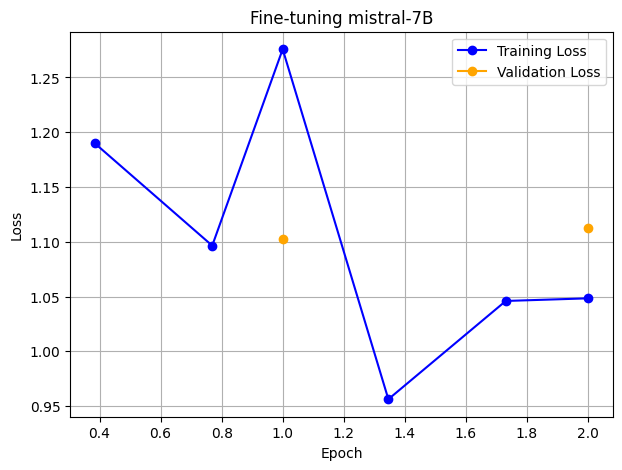

In [ ]:
plot_loss(trainer, 'Fine-tuning mistral-7B')

## Loading the model and adapter

In [ ]:
# Loading the base model
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.3")
model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.3",
    dtype=torch.float16,
    device_map="auto",
)

# Loading the fine-tuned adapter.
model.load_adapter(f"{HF_USER}/mistral-finetuned")

adapter_config.json:   0%|          | 0.00/780 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

Using a pipeline to test the 4 different queries

In [ ]:
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
pipe("""### Human: What is the capital of Germany? Explain why thats the case \
    and if it was different in the past?### Assistant:""", max_new_tokens=100)
pipe("""### Human: Write a Python function to calculate the factorial of a \
    number.### Assistant:""", max_new_tokens=100)
pipe("""### Human: A rectangular garden has a length of 25 feet and a width of \
    15 feet. If you want to build a fence around the entire garden, how many \
    feet of fencing will you need?### Assistant:""", max_new_tokens=100)
pipe_out = pipe("""### Human: What is the difference between a fruit and a vegetable? Give \
examples of each.### Assistant:""", max_new_tokens=100)
print(pipe_out[0]['generated_text'])

### Human: What is the difference between a fruit and a vegetable? Give examples of each.### Assistant: Fruits are the edible parts of a plant that contain seeds and develop from the flower of the plant. They are typically sweet and can be eaten fresh or cooked. Examples of fruits include apples, bananas, oranges, and strawberries.

Vegetables, on the other hand, are the edible parts of a plant that do not contain seeds and do not develop from the flower of the plant. They are typically savory and can be eaten fresh or cooked


Using the chat template

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/Mistral-7B-v0.3")
chat = [
    {"role": "user", "content": """What is the capital of Germany? Explain why thats the case \
    and if it was different in the past?"""}
]
tokenized_chat = tokenizer.apply_chat_template(chat, tokenize=False)
outputs = model.generate(tokenized_chat, max_new_tokens=128)
print(tokenizer.decode(outputs[0]))

OSError: HuggingFaceTB/Mistral-7B-v0.3 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

Using a function

In [ ]:
def generate_text(prompt):
    return pipe(f"### Human: {prompt}### Assistant:", max_new_tokens=100)

In [ ]:
generate_text("""What is the capital of Germany? Explain why thats the case and
              if it was different in the past?""")
generate_text("Write a Python function to calculate the factorial of a number.")
generate_text("""A rectangular garden has a length of 25 feet and a width of 15
              feet. If you want to build a fence around the entire garden, how
              many feet of fencing will you need?""")
pipe_out = generate_text("""What is the difference between a fruit and a vegetable? Give \
examples of each.""")
print(pipe_out[0]['generated_text'])

### Human: What is the difference between a fruit and a vegetable? Give               \examples of each.### Assistant: A fruit is a type of plant that contains seeds and is often sweet and juicy. Examples of fruits include apples, bananas, strawberries, and watermelon.

A vegetable, on the other hand, is a type of plant that is grown for its edible parts, such as leaves, stems, roots, or tubers. Examples of vegetables include carrots, broccoli, spinach, and potatoes.

It's important to note


# Function to consider using

In [ ]:
# Function taken from the NLP repository to wrap text.
# Source: https://github.com/nlp-with-transformers/notebooks/blob/main/utils.py
def wrap_print_text(print):
    def wrapped_func(text):
        if not isinstance(text, str):
            text = str(text)
        wrapper = TextWrapper(
            width=80,
            break_long_words=True,
            break_on_hyphens=False,
            replace_whitespace=False,
        )
        return print("\n".join(wrapper.fill(line) for line in text.split("\n")))
    return wrapped_func
print = wrap_print_text(print)